This Notebook is for exporatory data analysis of the MNIST dataset, we do the following
01_eda.ipynb
│
├── 1. Load data using PyTorch DataLoader
├── 2. Visualize sample digits
├── 3. Class distribution
├── 4. Pixel intensity distribution
└── 5. Mean digit images per class

In [15]:
import torch 
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
#%matplotlib inline
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader


In [16]:
dataset = MNIST(root='./data', train=True, download=True)
print(len(dataset))

60000


Image shape: (28, 28), Label: 5


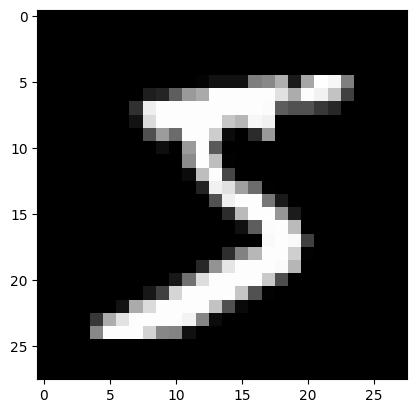

In [17]:
image, label = dataset[0]
print(f"Image shape: {image.size}, Label: {label}") 
plt.imshow(image, cmap='gray')


In [8]:
train_data = MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

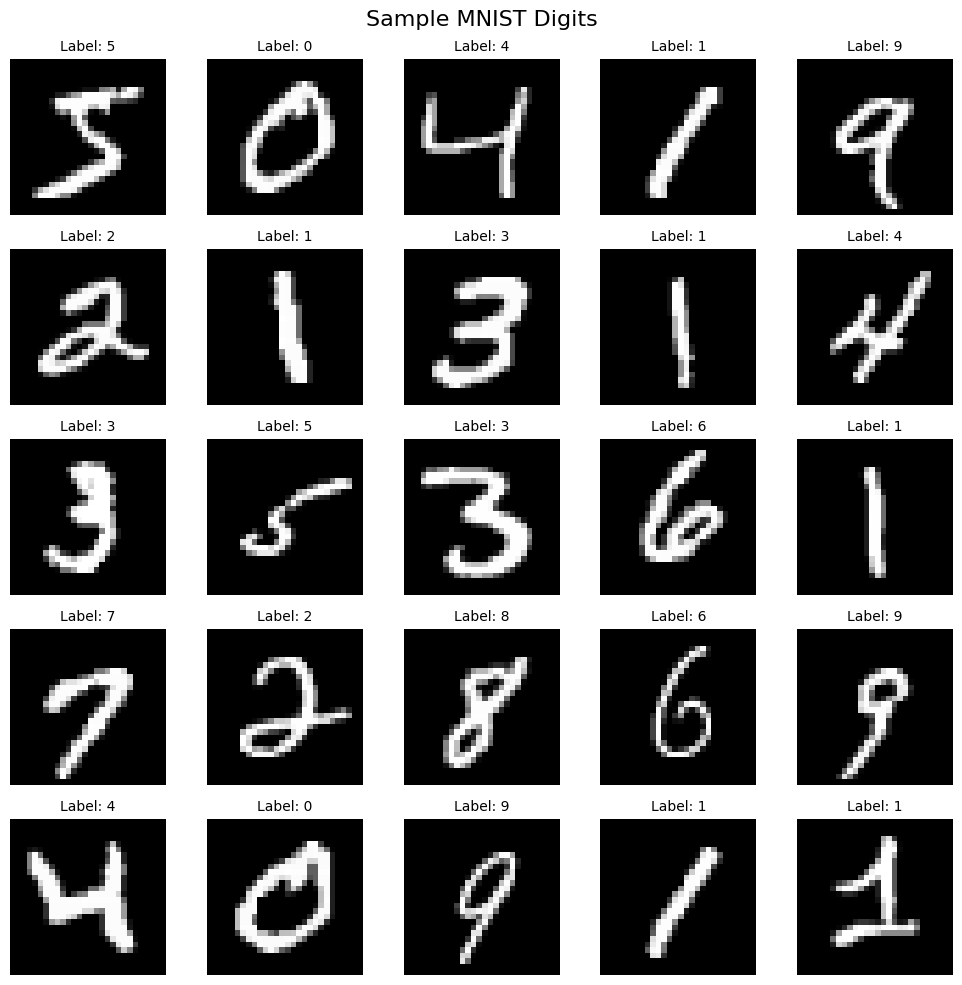

In [18]:
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]
    ax.imshow(image.squeeze().numpy(), cmap='gray')
    ax.set_title(f"Label: {label}", fontsize=10)
    ax.axis('off')

plt.suptitle("Sample MNIST Digits", fontsize=16)
plt.tight_layout()
plt.show()

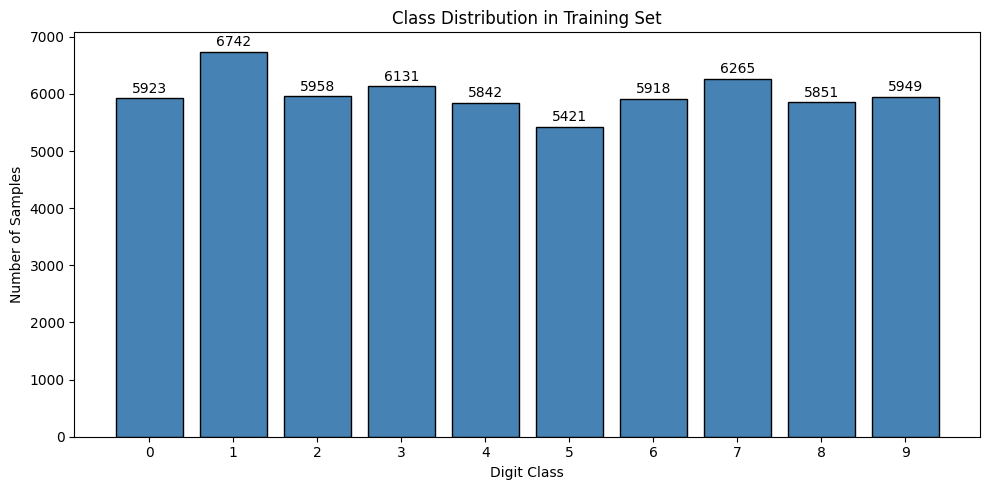

In [19]:
labels = [label for _, label in train_data]
fig, ax = plt.subplots(figsize = (10,5))
ax.bar(range(10), [labels.count(i) for i in range(10)], color='steelblue', edgecolor='black')
ax.set_xticks(range(10))
ax.set_xlabel("Digit Class")
ax.set_ylabel("Number of Samples")
ax.set_title("Class Distribution in Training Set")
for i in range(10):
    ax.text(i, labels.count(i) + 50, str(labels.count(i)), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [22]:
mean_images = []

for digit in range(10):
    digit_images = [train_data[i][0].squeeze().numpy() 
                    for i in range(len(train_data)) 
                    if train_data[i][1] == digit]
    mean_images.append(np.mean(digit_images, axis=0))

print(mean_images)

[array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.47477349e-05,
        1.67509177e-04, 6.88575310e-05, 0.00000000e+00, 5.95882484e-05,
        1.62874538e-04, 7.74647197e-05, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.0000

In [26]:
all_pixels = torch.stack([train_data[i][0] for i in range(len(train_data))]).numpy().flatten()
print(all_pixels[0])

0.0


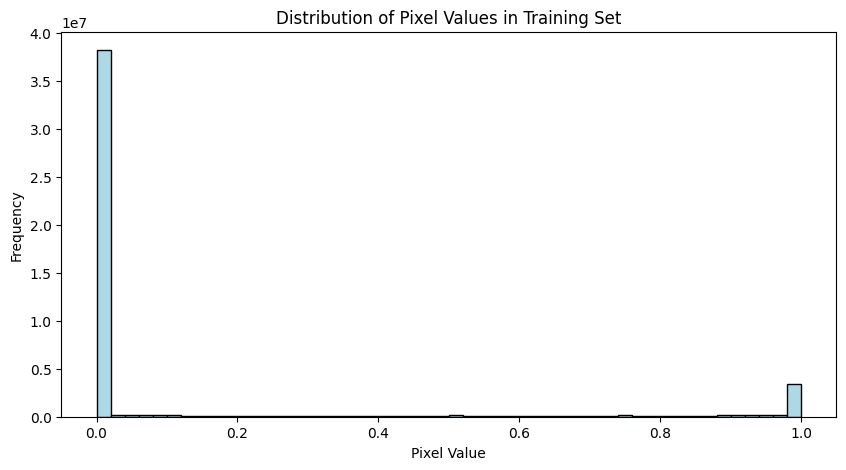

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(all_pixels, bins=50, color='lightblue', edgecolor='black')
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("Distribution of Pixel Values in Training Set")
plt.show()

In [30]:
BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")
print(f"Batch label shape : {labels.shape}")
print(f"Total train batches : {len(train_loader)}")
print(f"Total test  batches : {len(test_loader)}")

Batch image shape : torch.Size([64, 1, 28, 28])
Batch label shape : torch.Size([64])
Total train batches : 938
Total test  batches : 157
